# ST3189: Machine Learning — Assessed Coursework Project
**Candidate Number:** [YOUR CANDIDATE NUMBER]

---

## Table of Contents
1. [Setup & Data Loading](#setup)
2. [Unsupervised Learning — FIFA Player Clustering](#unsupervised)
3. [Regression — Player Market Value Prediction](#regression)
4. [Classification — Mushroom Edibility](#classification)

---
> **Datasets:**
> - FIFA Player Performance & Market Value: `fifa_player_performance_market_value.csv`
> - UCI Mushroom Dataset: `mushrooms.csv`


---
## 1. Setup & Data Loading <a id='setup'></a>

In [1]:
# ── Core libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import f_oneway

# ── Sklearn: preprocessing ──────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA

# ── Sklearn: clustering ─────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)

# ── Sklearn: models ─────────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# ── XGBoost ─────────────────────────────────────────────────
from xgboost import XGBRegressor

# ── Plot settings ────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})
sns.set_palette("Set2")

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# ── Load datasets ────────────────────────────────────────────
fifa = pd.read_csv('fifa_player_performance_market_value.csv')
mushroom = pd.read_csv('mushrooms.csv')

print(f"FIFA dataset:    {fifa.shape[0]:,} rows × {fifa.shape[1]} columns")
print(f"Mushroom dataset:{mushroom.shape[0]:,} rows × {mushroom.shape[1]} columns")

FIFA dataset:    2,800 rows × 16 columns
Mushroom dataset:8,124 rows × 23 columns


In [3]:
# ── Quick overview ────────────────────────────────────────────
print("=== FIFA Dataset — First 5 Rows ===")
display(fifa.head())
print("\n=== FIFA Dataset — Data Types & Nulls ===")
display(fifa.info())

=== FIFA Dataset — First 5 Rows ===


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low



=== FIFA Dataset — Data Types & Nulls ===
<class 'pandas.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 2800 non-null   int64  
 1   player_name               2800 non-null   str    
 2   age                       2800 non-null   int64  
 3   nationality               2800 non-null   str    
 4   club                      2800 non-null   str    
 5   position                  2800 non-null   str    
 6   overall_rating            2800 non-null   int64  
 7   potential_rating          2800 non-null   int64  
 8   matches_played            2800 non-null   int64  
 9   goals                     2800 non-null   int64  
 10  assists                   2800 non-null   int64  
 11  minutes_played            2800 non-null   int64  
 12  market_value_million_eur  2800 non-null   float64
 13  contract_years_left       2800 

None

In [4]:
print("=== Mushroom Dataset — First 5 Rows ===")
display(mushroom.head())
print("\n=== Mushroom Dataset — Data Types ===")
display(mushroom.info())

=== Mushroom Dataset — First 5 Rows ===


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g



=== Mushroom Dataset — Data Types ===
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-

None

In [5]:
# ── Descriptive statistics ────────────────────────────────────
print("=== FIFA — Descriptive Statistics ===")
display(fifa.describe().round(2))

=== FIFA — Descriptive Statistics ===


,player_id,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
count,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00,2800.00
mean,1400.50,27.95,76.87,81.56,27.14,19.26,12.02,2250.10,90.57,2.53
std,808.43,6.75,9.92,9.76,15.98,11.57,7.19,1295.46,52.08,1.70
min,1.00,17.00,60.00,65.00,0.00,0.00,0.00,0.00,0.67,0.00
25%,700.75,22.00,68.00,73.00,13.75,9.00,6.00,1131.25,45.36,1.00
50%,1400.50,28.00,77.00,82.00,27.00,19.00,12.00,2251.00,89.17,3.00
75%,2100.25,34.00,85.00,90.00,41.00,30.00,18.00,3366.25,136.68,4.00
max,2800.00,39.00,94.00,98.00,54.00,39.00,24.00,4497.00,179.96,5.00


---
## 2. Unsupervised Learning: FIFA Player Clustering <a id='unsupervised'></a>

### 2.1 Dataset and Problem Statement

We apply unsupervised clustering to the FIFA Player dataset to discover natural player archetypes based on performance and market metrics — without using pre-defined labels such as position or club. The goal is to identify homogeneous groups of players that could inform talent scouting and squad planning.

### 2.2 Feature Selection & Preprocessing

In [6]:
# Select numeric features for clustering (drop ID, name, and categorical columns)
cluster_features = [
    'age', 'overall_rating', 'potential_rating',
    'matches_played', 'goals', 'assists',
    'minutes_played', 'market_value_million_eur', 'contract_years_left'
]

X_cluster = fifa[cluster_features].copy()

# Check for missing values
print("Missing values per feature:")
print(X_cluster.isnull().sum())
X_cluster = X_cluster.dropna()
print(f"\nFinal clustering dataset: {X_cluster.shape[0]:,} rows × {X_cluster.shape[1]} features")

Missing values per feature:


age                         0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
dtype: int64

Final clustering dataset: 2,800 rows × 9 features


In [7]:
# Z-score standardisation — essential for distance-based clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Standardised feature means (should be ~0):")
print(np.round(X_scaled.mean(axis=0), 4))
print("\nStandardised feature std deviations (should be ~1):")
print(np.round(X_scaled.std(axis=0), 4))

Standardised feature means (should be ~0):
[-0.  0. -0. -0. -0. -0. -0. -0. -0.]

Standardised feature std deviations (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 2.3 Exploratory Data Analysis

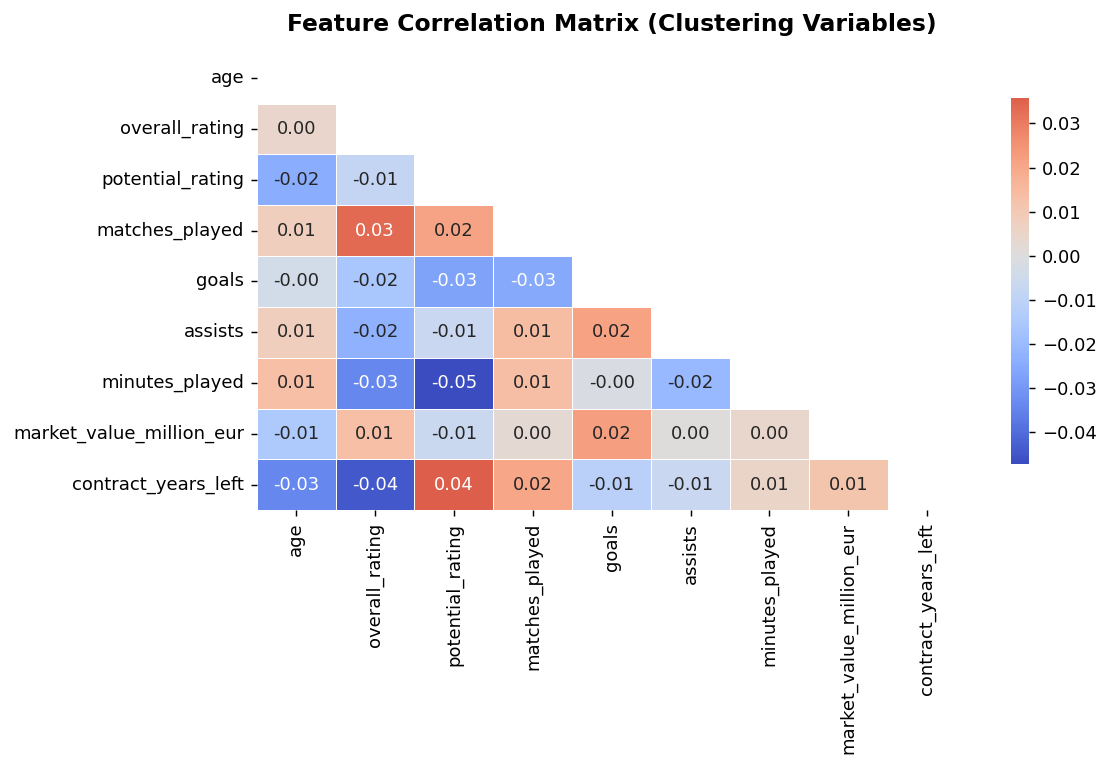

Figure saved: fig_correlation_heatmap.png


In [8]:
# Correlation heatmap of clustering features
fig, ax = plt.subplots(figsize=(9, 6))
corr = X_cluster.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (Clustering Variables)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_correlation_heatmap.png")

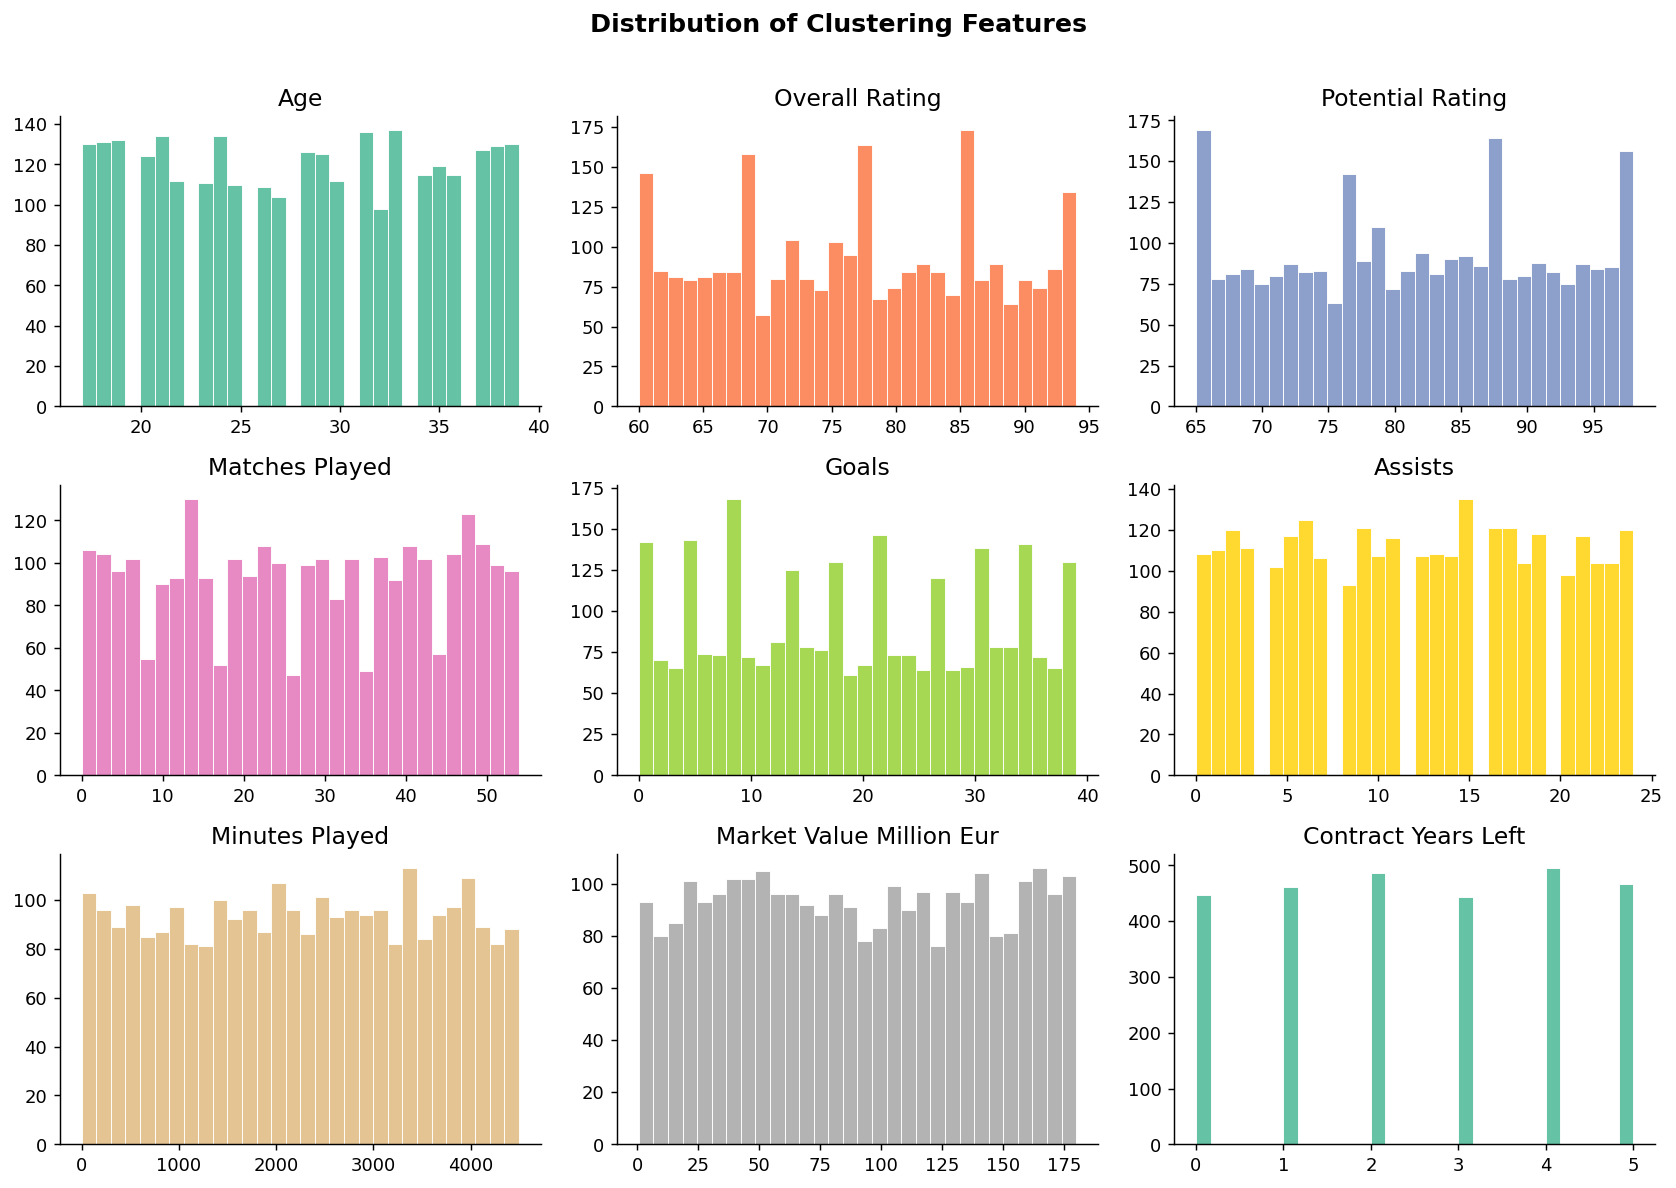

Figure saved: fig_feature_distributions.png


In [9]:
# Distribution plots of key features
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()
colors = sns.color_palette("Set2", len(cluster_features))

for i, (feat, color) in enumerate(zip(cluster_features, colors)):
    axes[i].hist(X_cluster[feat], bins=30, color=color, edgecolor='white', linewidth=0.5)
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Clustering Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_feature_distributions.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_feature_distributions.png")

### 2.4 Elbow Method & Optimal k

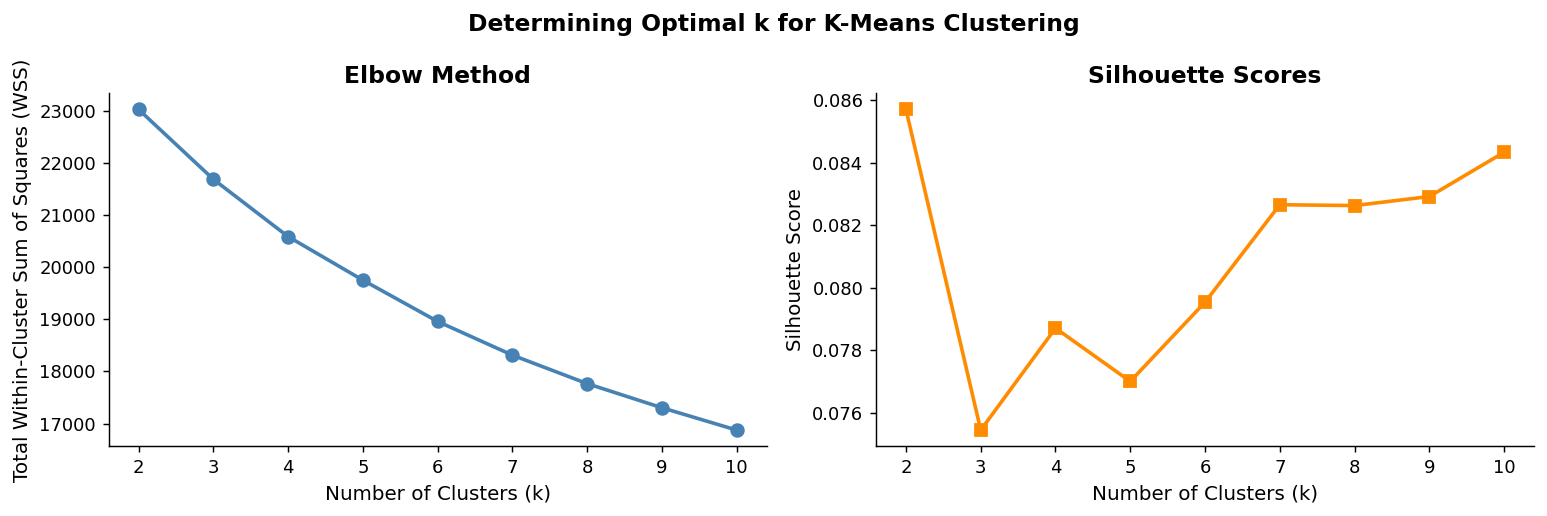

   k           WSS    Silhouette
--------------------------------
   2       23023.6        0.0857
   3       21684.7        0.0755
   4       20585.1        0.0787
   5       19749.8        0.0770
   6       18957.8        0.0795
   7       18311.9        0.0827
   8       17765.5        0.0826
   9       17303.1        0.0829
  10       16874.2        0.0843


In [10]:
# ── Elbow Method: WSS vs k ────────────────────────────────────
wss = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=25, random_state=42)
    labels = km.fit_predict(X_scaled)
    wss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
axes[0].plot(K_range, wss, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Total Within-Cluster Sum of Squares (WSS)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(K_range))

# Silhouette plot
axes[1].plot(K_range, sil_scores, 's-', color='darkorange', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores', fontweight='bold')
axes[1].set_xticks(list(K_range))

plt.suptitle('Determining Optimal k for K-Means Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_elbow_silhouette.png', bbox_inches='tight')
plt.show()

# Print table
print(f"{'k':>4}  {'WSS':>12}  {'Silhouette':>12}")
print("-" * 32)
for k, w, s in zip(K_range, wss, sil_scores):
    print(f"{k:>4}  {w:>12.1f}  {s:>12.4f}")

### 2.5 K-Means Clustering

In [11]:
# ── Apply K-Means with chosen k ───────────────────────────────
# UPDATE k_optimal based on elbow/silhouette results above
k_optimal = 4

km_final = KMeans(n_clusters=k_optimal, n_init=25, random_state=42)
fifa_clusters = fifa[cluster_features].dropna().copy()
fifa_clusters['kmeans_cluster'] = km_final.fit_predict(X_scaled)

print(f"K-Means with k={k_optimal}")
print("\nCluster sizes:")
print(fifa_clusters['kmeans_cluster'].value_counts().sort_index())

K-Means with k=4

Cluster sizes:
kmeans_cluster
0    736
1    704
2    652
3    708
Name: count, dtype: int64


In [12]:
# ── Cluster centroids (back-transformed to original scale) ────
centroids_df = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=cluster_features
).round(2)
centroids_df.index.name = 'Cluster'
print("=== Cluster Centroids (Original Scale) ===")
display(centroids_df)

=== Cluster Centroids (Original Scale) ===


,age,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left
Cluster,,,,,,,,,
0,29.98,78.30,72.11,27.35,20.18,13.93,2423.14,97.34,1.39
1,27.43,74.33,86.19,28.19,19.24,19.07,2222.20,92.96,3.51
2,26.52,78.94,89.17,27.23,18.86,8.90,1903.92,83.44,1.05
3,27.69,76.01,79.77,25.77,18.71,5.84,2416.15,87.68,4.09


PC1 explains 12.1% of variance
PC2 explains 11.9% of variance
Total: 23.9%


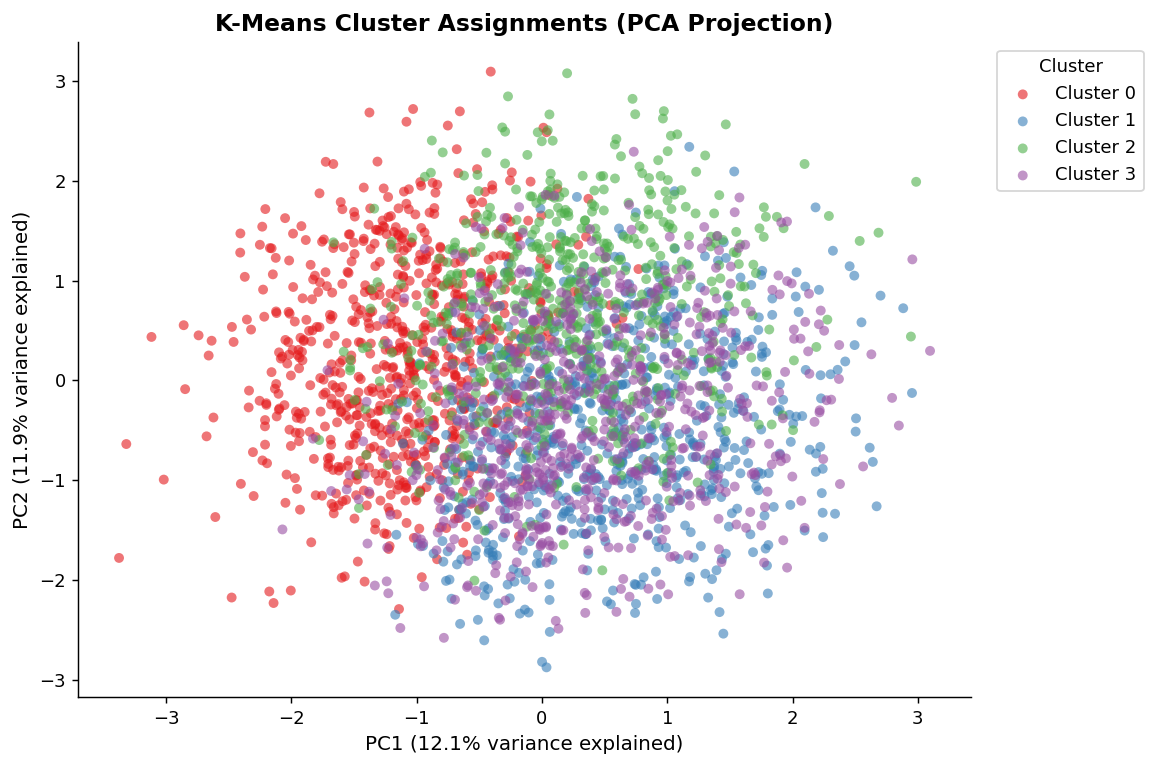

Figure saved: fig_kmeans_pca.png


In [13]:
# ── PCA visualisation of K-Means clusters ─────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {var_explained[0]:.1f}% of variance")
print(f"PC2 explains {var_explained[1]:.1f}% of variance")
print(f"Total: {sum(var_explained):.1f}%")

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette("Set1", k_optimal)
cluster_labels_map = {
    0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'
}  # Update with your interpreted labels after seeing centroids

for c in range(k_optimal):
    mask = fifa_clusters['kmeans_cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[palette[c]], label=cluster_labels_map.get(c, f'Cluster {c}'),
               alpha=0.6, s=30, edgecolors='none')

ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')
ax.set_title('K-Means Cluster Assignments (PCA Projection)', fontweight='bold')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_kmeans_pca.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_kmeans_pca.png")

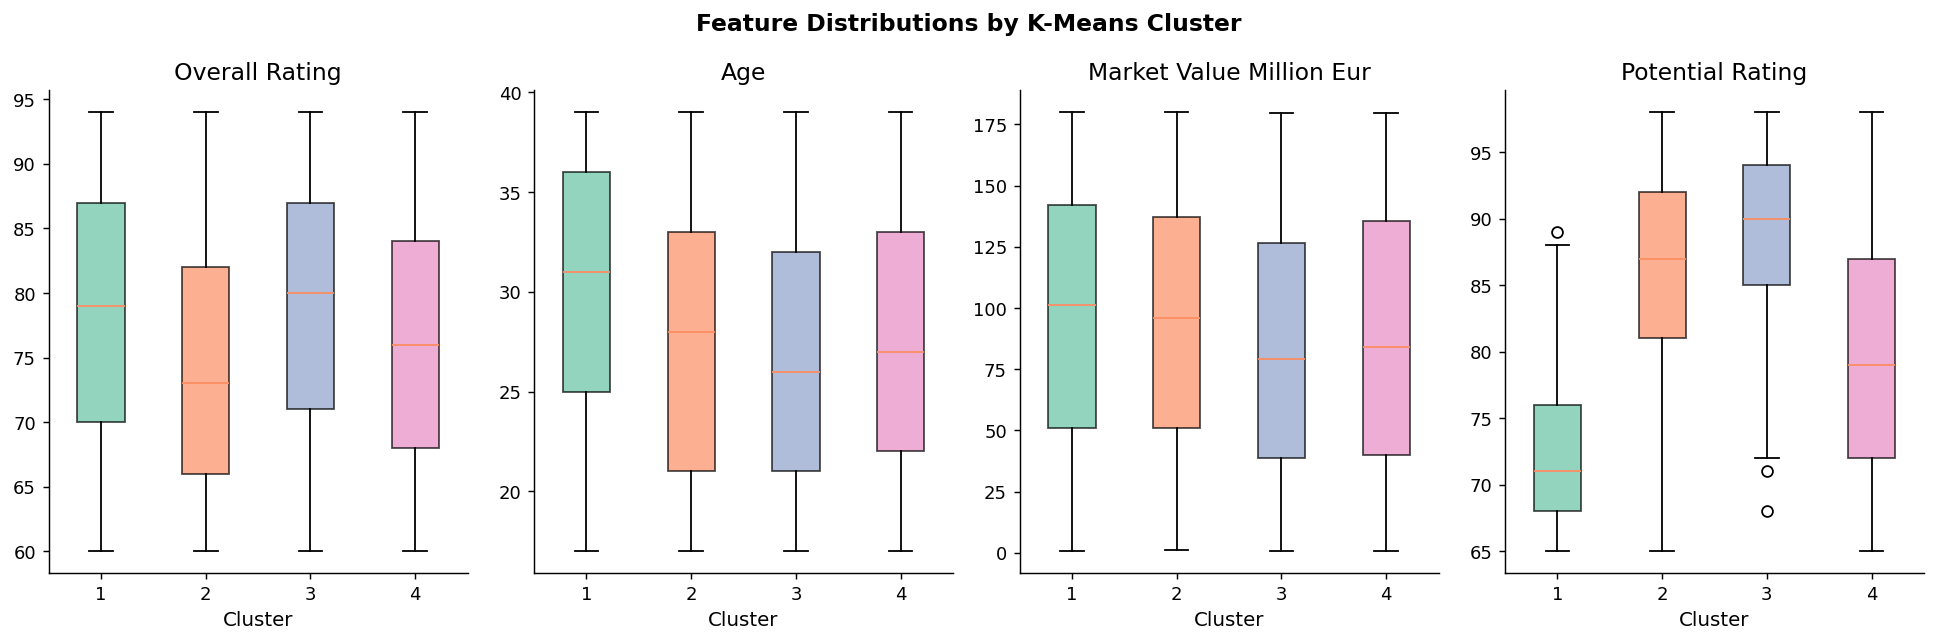

Figure saved: fig_cluster_boxplots.png


In [14]:
# ── Cluster profile boxplots ──────────────────────────────────
key_features = ['overall_rating', 'age', 'market_value_million_eur', 'potential_rating']
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for ax, feat in zip(axes, key_features):
    data_by_cluster = [
        fifa_clusters.loc[fifa_clusters['kmeans_cluster'] == c, feat].values
        for c in range(k_optimal)
    ]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, notch=False)
    palette = sns.color_palette("Set2", k_optimal)
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel('Cluster')

plt.suptitle('Feature Distributions by K-Means Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cluster_boxplots.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_cluster_boxplots.png")

### 2.6 Hierarchical Clustering

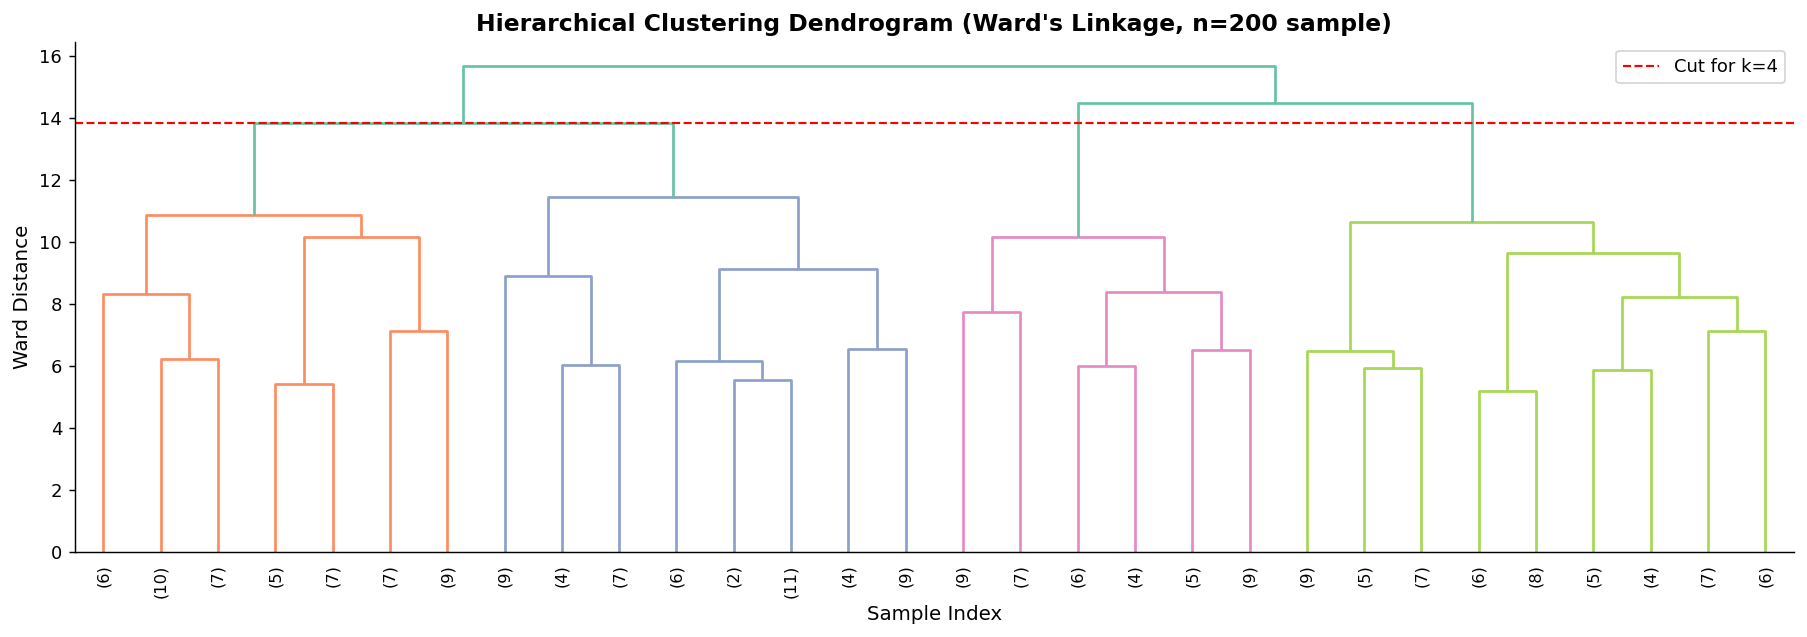

Figure saved: fig_dendrogram.png


In [15]:
# ── Compute linkage matrix (Ward's method) ────────────────────
# Use a sample for dendrogram clarity (Ward on full 2800 rows is dense)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=200, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

# ── Plot dendrogram ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z, ax=ax,
    truncate_mode='lastp', p=30,
    leaf_rotation=90, leaf_font_size=9,
    color_threshold=Z[-k_optimal+1, 2]
)
ax.axhline(y=Z[-k_optimal+1, 2], color='red', linestyle='--', linewidth=1.2,
           label=f'Cut for k={k_optimal}')
ax.set_title("Hierarchical Clustering Dendrogram (Ward's Linkage, n=200 sample)",
             fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Ward Distance')
ax.legend()
plt.tight_layout()
plt.savefig('fig_dendrogram.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_dendrogram.png")

In [16]:
# ── Apply hierarchical clustering to full dataset ─────────────
hc = AgglomerativeClustering(n_clusters=k_optimal, linkage='ward')
fifa_clusters['hc_cluster'] = hc.fit_predict(X_scaled)

print("Hierarchical cluster sizes:")
print(fifa_clusters['hc_cluster'].value_counts().sort_index())

# ── Adjusted Rand Index: agreement between K-Means and HC ─────
ari = adjusted_rand_score(fifa_clusters['kmeans_cluster'], fifa_clusters['hc_cluster'])
print(f"\nAdjusted Rand Index (K-Means vs Hierarchical): {ari:.4f}")
print("(ARI close to 1.0 = strong agreement between methods)")

Hierarchical cluster sizes:
hc_cluster
0    1006
1     644
2     535
3     615
Name: count, dtype: int64

Adjusted Rand Index (K-Means vs Hierarchical): 0.0666
(ARI close to 1.0 = strong agreement between methods)


In [17]:
# ── Cross-tabulation: cluster assignment agreement ─────────────
ct = pd.crosstab(
    fifa_clusters['kmeans_cluster'],
    fifa_clusters['hc_cluster'],
    rownames=['K-Means'], colnames=['Hierarchical']
)
print("Cross-tabulation of K-Means vs Hierarchical cluster assignments:")
display(ct)

Cross-tabulation of K-Means vs Hierarchical cluster assignments:


Hierarchical,0,1,2,3
K-Means,,,,
0,174,33,285,244
1,295,132,148,129
2,301,160,40,151
3,236,319,62,91


---
## 3. Regression: Player Market Value Prediction <a id='regression'></a>

### 3.1 Dataset and Problem Statement

We predict `market_value_million_eur` using player performance attributes. This is a supervised regression task. The target variable is log-transformed to address positive skewness common in financial data.

### 3.2 Feature Engineering & Preprocessing

In [18]:
# ── Prepare regression dataset ────────────────────────────────
reg_df = fifa.drop(columns=['player_id', 'player_name', 'nationality', 'club']).copy()

# Encode binary categorical variables
reg_df['injury_prone'] = (reg_df['injury_prone'] == 'Yes').astype(int)
reg_df['transfer_risk_level'] = reg_df['transfer_risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

# One-hot encode position
reg_df = pd.get_dummies(reg_df, columns=['position'], drop_first=True)

print(f"Regression dataset shape: {reg_df.shape}")
print("\nTarget variable statistics (market_value_million_eur):")
display(reg_df['market_value_million_eur'].describe().round(2))

Regression dataset shape: (2800, 19)

Target variable statistics (market_value_million_eur):


count    2800.00
mean       90.57
std        52.08
min         0.67
25%        45.36
50%        89.17
75%       136.68
max       179.96
Name: market_value_million_eur, dtype: float64

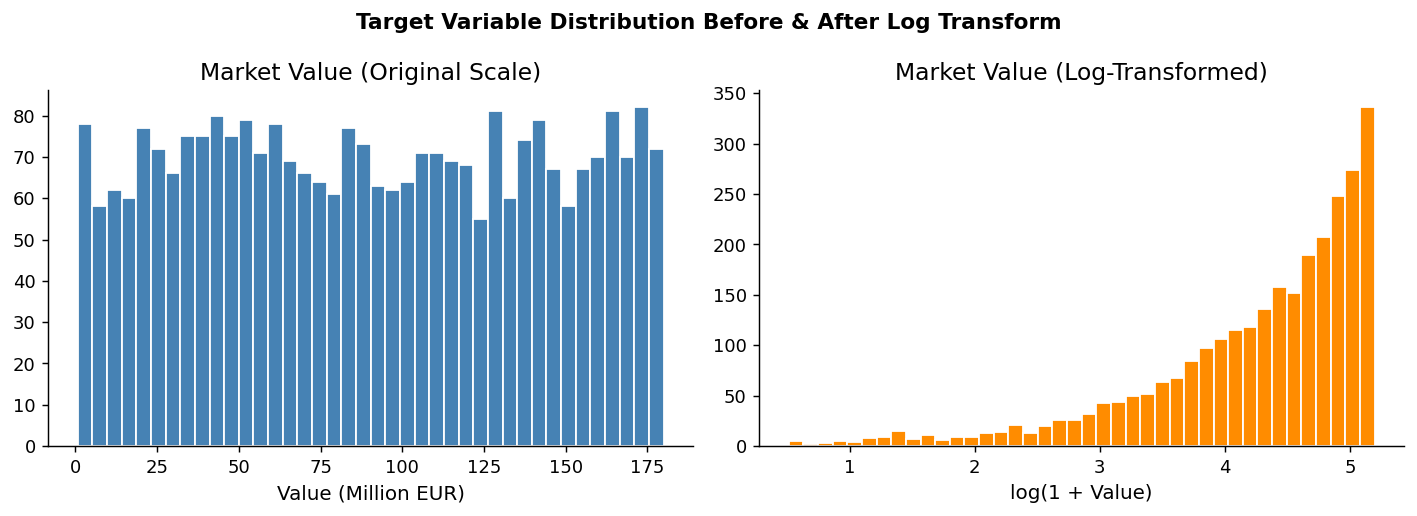

Figure saved: fig_target_distribution.png


In [19]:
# ── Log-transform the target ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(reg_df['market_value_million_eur'], bins=40,
             color='steelblue', edgecolor='white')
axes[0].set_title('Market Value (Original Scale)')
axes[0].set_xlabel('Value (Million EUR)')

reg_df['log_market_value'] = np.log1p(reg_df['market_value_million_eur'])

axes[1].hist(reg_df['log_market_value'], bins=40,
             color='darkorange', edgecolor='white')
axes[1].set_title('Market Value (Log-Transformed)')
axes[1].set_xlabel('log(1 + Value)')

plt.suptitle('Target Variable Distribution Before & After Log Transform',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_target_distribution.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_target_distribution.png")

In [20]:
# ── Train / test split ────────────────────────────────────────
feature_cols = [c for c in reg_df.columns
                if c not in ['market_value_million_eur', 'log_market_value']]

X_reg = reg_df[feature_cols]
y_reg = reg_df['log_market_value']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train_r.shape[0]:,} samples")
print(f"Test set:      {X_test_r.shape[0]:,} samples")
print(f"Features used: {X_train_r.shape[1]}")

Training set:  2,240 samples
Test set:      560 samples
Features used: 18


### 3.3 Model Training

In [21]:
# ── Model 1: Multiple Linear Regression ──────────────────────
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_lr = lr.predict(X_test_r)

rmse_lr  = np.sqrt(mean_squared_error(y_test_r, y_pred_lr))
mae_lr   = mean_absolute_error(y_test_r, y_pred_lr)
r2_lr    = r2_score(y_test_r, y_pred_lr)

print(f"Multiple Linear Regression")
print(f"  RMSE : {rmse_lr:.4f}")
print(f"  MAE  : {mae_lr:.4f}")
print(f"  R²   : {r2_lr:.4f}")

Multiple Linear Regression
  RMSE : 0.8917
  MAE  : 0.6962
  R²   : -0.0090


In [22]:
# ── Model 2: Random Forest Regressor ─────────────────────────
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf = rf_reg.predict(X_test_r)

rmse_rf  = np.sqrt(mean_squared_error(y_test_r, y_pred_rf))
mae_rf   = mean_absolute_error(y_test_r, y_pred_rf)
r2_rf    = r2_score(y_test_r, y_pred_rf)

print(f"Random Forest Regressor")
print(f"  RMSE : {rmse_rf:.4f}")
print(f"  MAE  : {mae_rf:.4f}")
print(f"  R²   : {r2_rf:.4f}")

Random Forest Regressor
  RMSE : 0.9101
  MAE  : 0.7191
  R²   : -0.0510


In [23]:
# ── Model 3: XGBoost Regressor ────────────────────────────────
xgb = XGBRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=5, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    verbosity=0, eval_metric='rmse'
)
xgb.fit(X_train_r, y_train_r)
y_pred_xgb = xgb.predict(X_test_r)

rmse_xgb  = np.sqrt(mean_squared_error(y_test_r, y_pred_xgb))
mae_xgb   = mean_absolute_error(y_test_r, y_pred_xgb)
r2_xgb    = r2_score(y_test_r, y_pred_xgb)

print(f"XGBoost Regressor")
print(f"  RMSE : {rmse_xgb:.4f}")
print(f"  MAE  : {mae_xgb:.4f}")
print(f"  R²   : {r2_xgb:.4f}")

XGBoost Regressor
  RMSE : 0.9316
  MAE  : 0.7261
  R²   : -0.1013


### 3.4 Results & Evaluation

In [24]:
# ── Model comparison table ────────────────────────────────────
results_reg = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE':  [rmse_lr,  rmse_rf,  rmse_xgb],
    'MAE':   [mae_lr,   mae_rf,   mae_xgb],
    'R²':    [r2_lr,    r2_rf,    r2_xgb]
}).round(4)

results_reg = results_reg.sort_values('R²', ascending=False).reset_index(drop=True)
print("=== Regression Model Performance (Test Set, log-scale target) ===")
display(results_reg)

=== Regression Model Performance (Test Set, log-scale target) ===


,Model,RMSE,MAE,R²
0,Linear Regression,0.8917,0.6962,-0.0090
1,Random Forest,0.9101,0.7191,-0.0510
2,XGBoost,0.9316,0.7261,-0.1013


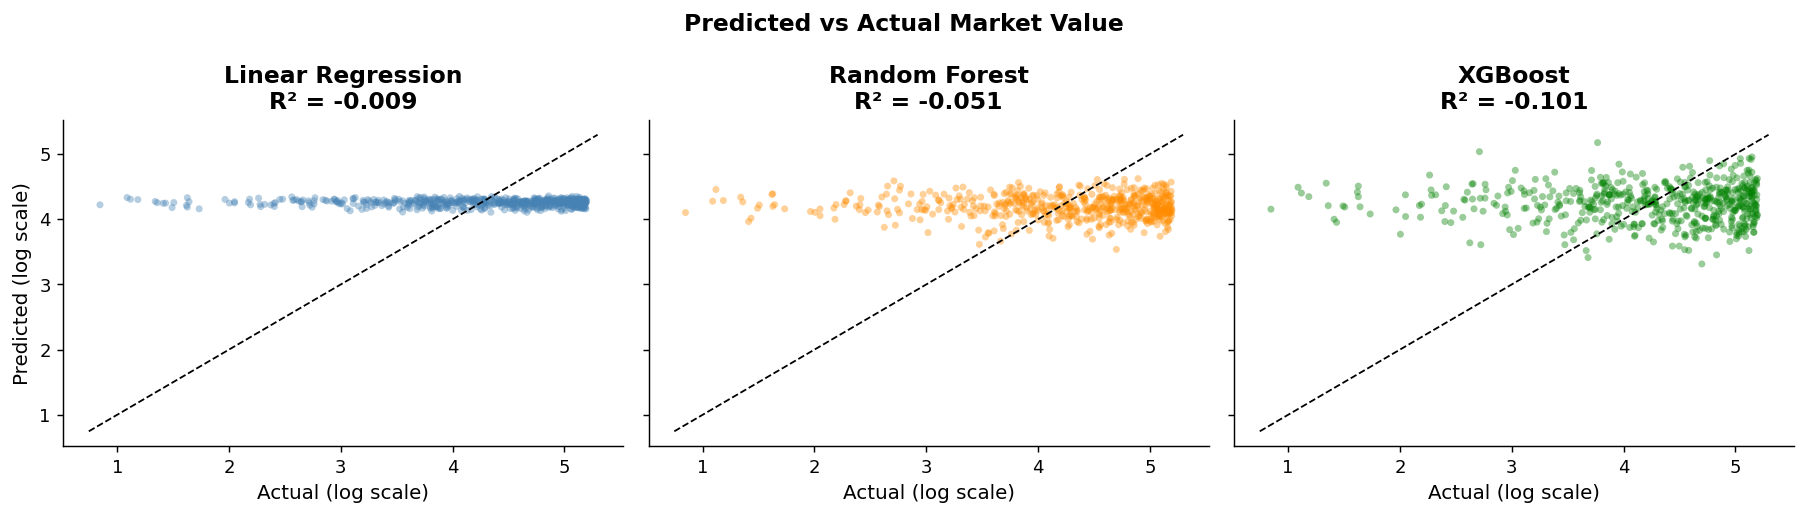

Figure saved: fig_regression_scatter.png


In [25]:
# ── Predicted vs Actual scatter plots ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

models_info = [
    ('Linear Regression', y_pred_lr,  'steelblue'),
    ('Random Forest',     y_pred_rf,  'darkorange'),
    ('XGBoost',           y_pred_xgb, 'green')
]

for ax, (name, y_pred, color) in zip(axes, models_info):
    ax.scatter(y_test_r, y_pred, alpha=0.4, s=15, c=color, edgecolors='none')
    lims = [min(y_test_r.min(), y_pred.min()) - 0.1,
            max(y_test_r.max(), y_pred.max()) + 0.1]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect fit')
    r2 = r2_score(y_test_r, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.3f}', fontweight='bold')
    ax.set_xlabel('Actual (log scale)')
axes[0].set_ylabel('Predicted (log scale)')

plt.suptitle('Predicted vs Actual Market Value', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_regression_scatter.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_regression_scatter.png")

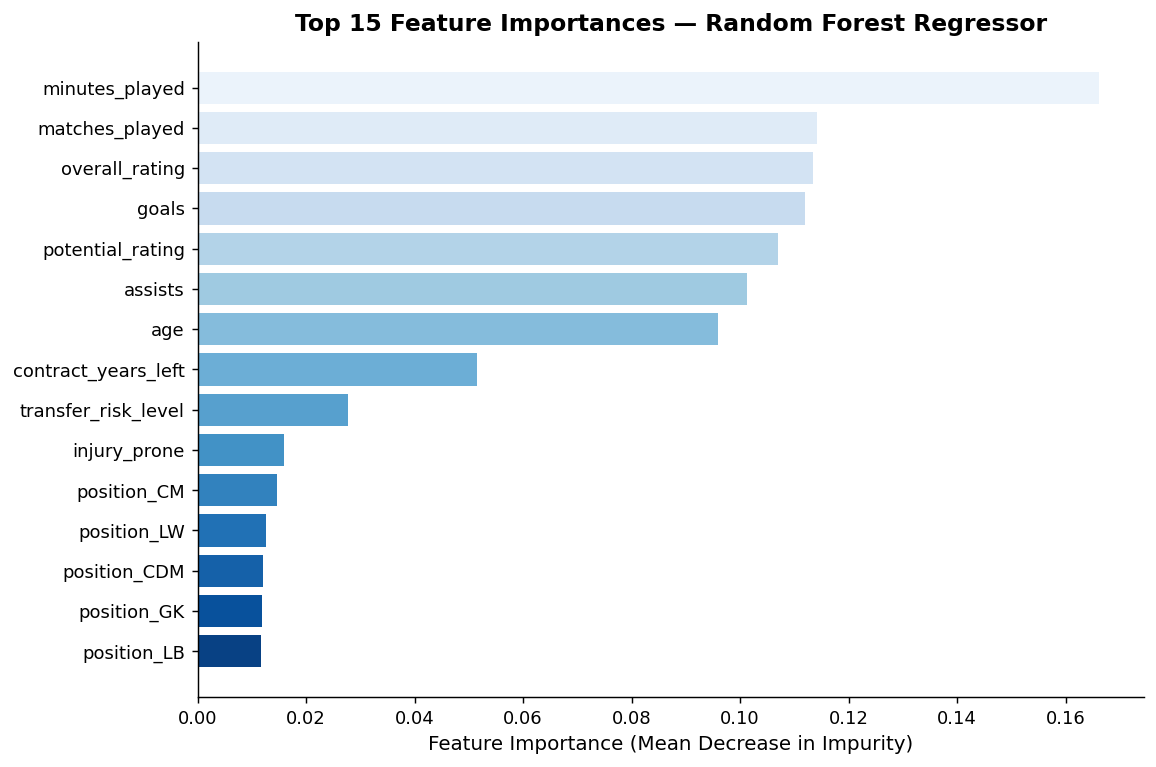

Figure saved: fig_feature_importance_reg.png


In [26]:
# ── Feature importance: Random Forest ────────────────────────
feat_imp = pd.Series(
    rf_reg.feature_importances_, index=feature_cols
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(feat_imp.index, feat_imp.values,
               color=sns.color_palette("Blues_r", len(feat_imp)))
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Top 15 Feature Importances — Random Forest Regressor', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance_reg.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_feature_importance_reg.png")

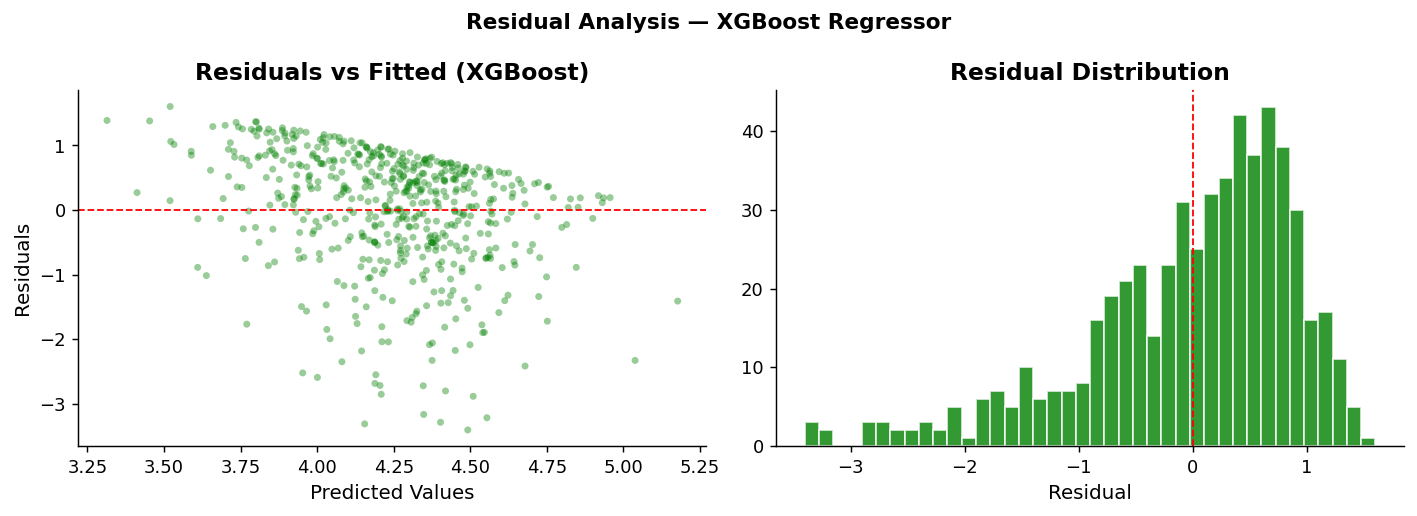

Figure saved: fig_residuals.png


In [27]:
# ── Residual analysis for best model (XGBoost) ───────────────
residuals = y_test_r.values - y_pred_xgb
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_pred_xgb, residuals, alpha=0.4, s=15, color='green', edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (XGBoost)', fontweight='bold')

axes[1].hist(residuals, bins=40, color='green', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Residual Analysis — XGBoost Regressor', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_residuals.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_residuals.png")

In [28]:
# ── Cross-validation on best model ───────────────────────────
cv_scores = cross_val_score(
    XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                 subsample=0.8, colsample_bytree=0.8, random_state=42,
                 verbosity=0),
    X_reg, y_reg, cv=5, scoring='r2', n_jobs=-1
)
print(f"XGBoost 5-Fold Cross-Validation R² scores: {cv_scores.round(4)}")
print(f"Mean R²: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

XGBoost 5-Fold Cross-Validation R² scores: [-0.116  -0.1259 -0.1348 -0.1326 -0.1333]
Mean R²: -0.1285  |  Std: 0.0070


---
## 4. Classification: Mushroom Edibility <a id='classification'></a>

### 4.1 Dataset and Problem Statement

We classify mushrooms as **edible (e)** or **poisonous (p)** using 22 categorical morphological features. This is a safety-critical binary classification problem — minimising false negatives (poisonous classified as edible) is the top priority, so **Recall for the poisonous class** is the primary evaluation metric alongside overall accuracy.

### 4.2 Preprocessing

Class distribution:
class
e    4208
p    3916
Name: count, dtype: int64

Edible:   4,208 (51.8%)
Poisonous:3,916 (48.2%)


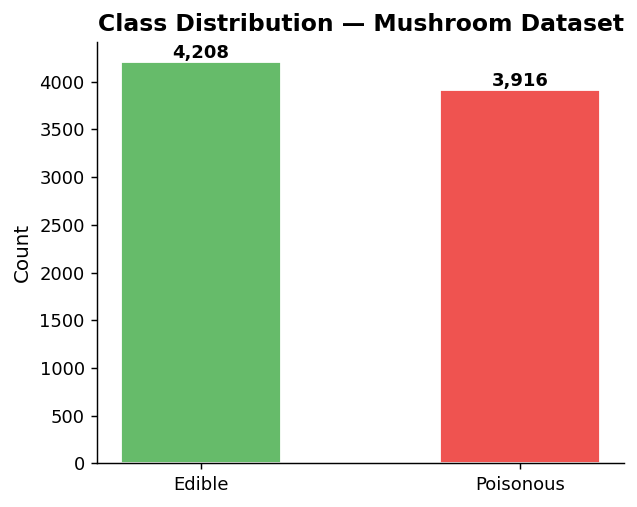

In [29]:
# ── Target & class distribution ───────────────────────────────
print("Class distribution:")
print(mushroom['class'].value_counts())
print(f"\nEdible:   {(mushroom['class']=='e').sum():,} ({(mushroom['class']=='e').mean()*100:.1f}%)")
print(f"Poisonous:{(mushroom['class']=='p').sum():,} ({(mushroom['class']=='p').mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
counts = mushroom['class'].value_counts()
ax.bar(['Edible', 'Poisonous'], counts.values,
       color=['#66BB6A', '#EF5350'], edgecolor='white', width=0.5)
ax.set_ylabel('Count')
ax.set_title('Class Distribution — Mushroom Dataset', fontweight='bold')
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()

In [30]:
# ── Drop veil-type (single unique value — no discriminatory power) ──
print("Unique values per feature:")
for col in mushroom.columns:
    print(f"  {col}: {mushroom[col].nunique()} unique values")

Unique values per feature:
  class: 2 unique values
  cap-shape: 6 unique values
  cap-surface: 4 unique values
  cap-color: 10 unique values
  bruises: 2 unique values
  odor: 9 unique values
  gill-attachment: 2 unique values
  gill-spacing: 2 unique values
  gill-size: 2 unique values
  gill-color: 12 unique values
  stalk-shape: 2 unique values
  stalk-root: 5 unique values
  stalk-surface-above-ring: 4 unique values
  stalk-surface-below-ring: 4 unique values
  stalk-color-above-ring: 9 unique values
  stalk-color-below-ring: 9 unique values
  veil-type: 1 unique values
  veil-color: 4 unique values
  ring-number: 3 unique values
  ring-type: 5 unique values
  spore-print-color: 9 unique values
  population: 6 unique values
  habitat: 7 unique values


In [31]:
# ── One-hot encode all features ───────────────────────────────
mush_enc = mushroom.drop(columns=['veil-type']).copy()

# Encode target
mush_enc['class'] = (mush_enc['class'] == 'p').astype(int)  # 1 = poisonous, 0 = edible

X_mush = pd.get_dummies(mush_enc.drop(columns=['class']), drop_first=True)
y_mush = mush_enc['class']

print(f"Feature matrix shape after one-hot encoding: {X_mush.shape}")
print(f"Target: 1=Poisonous, 0=Edible")
print(f"Class balance: {y_mush.mean()*100:.1f}% poisonous")

Feature matrix shape after one-hot encoding: (8124, 95)
Target: 1=Poisonous, 0=Edible
Class balance: 48.2% poisonous


In [32]:
# ── Train / test split ────────────────────────────────────────
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mush, y_mush, test_size=0.2, stratify=y_mush, random_state=42
)
print(f"Training set: {X_train_m.shape[0]:,} samples")
print(f"Test set:     {X_test_m.shape[0]:,} samples")

Training set: 6,499 samples
Test set:     1,625 samples


### 4.3 Model Training

In [33]:
# ── Model 1: Logistic Regression ─────────────────────────────
log_reg = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
log_reg.fit(X_train_m, y_train_m)
y_pred_log  = log_reg.predict(X_test_m)
y_prob_log  = log_reg.predict_proba(X_test_m)[:, 1]

print("Logistic Regression — Classification Report:")
print(classification_report(y_test_m, y_pred_log,
                             target_names=['Edible', 'Poisonous']))

Logistic Regression — Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [34]:
# ── Model 2: Decision Tree ────────────────────────────────────
# Tune max_depth with cross-validation
dt_scores = []
depths = range(2, 16)
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    score = cross_val_score(dt, X_train_m, y_train_m, cv=5,
                            scoring='recall').mean()
    dt_scores.append(score)

best_depth = depths[np.argmax(dt_scores)]
print(f"Best max_depth by 5-fold CV recall: {best_depth}")

dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train_m, y_train_m)
y_pred_dt = dt.predict(X_test_m)
y_prob_dt = dt.predict_proba(X_test_m)[:, 1]

print("\nDecision Tree — Classification Report:")
print(classification_report(y_test_m, y_pred_dt,
                             target_names=['Edible', 'Poisonous']))

Best max_depth by 5-fold CV recall: 5

Decision Tree — Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       0.99      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



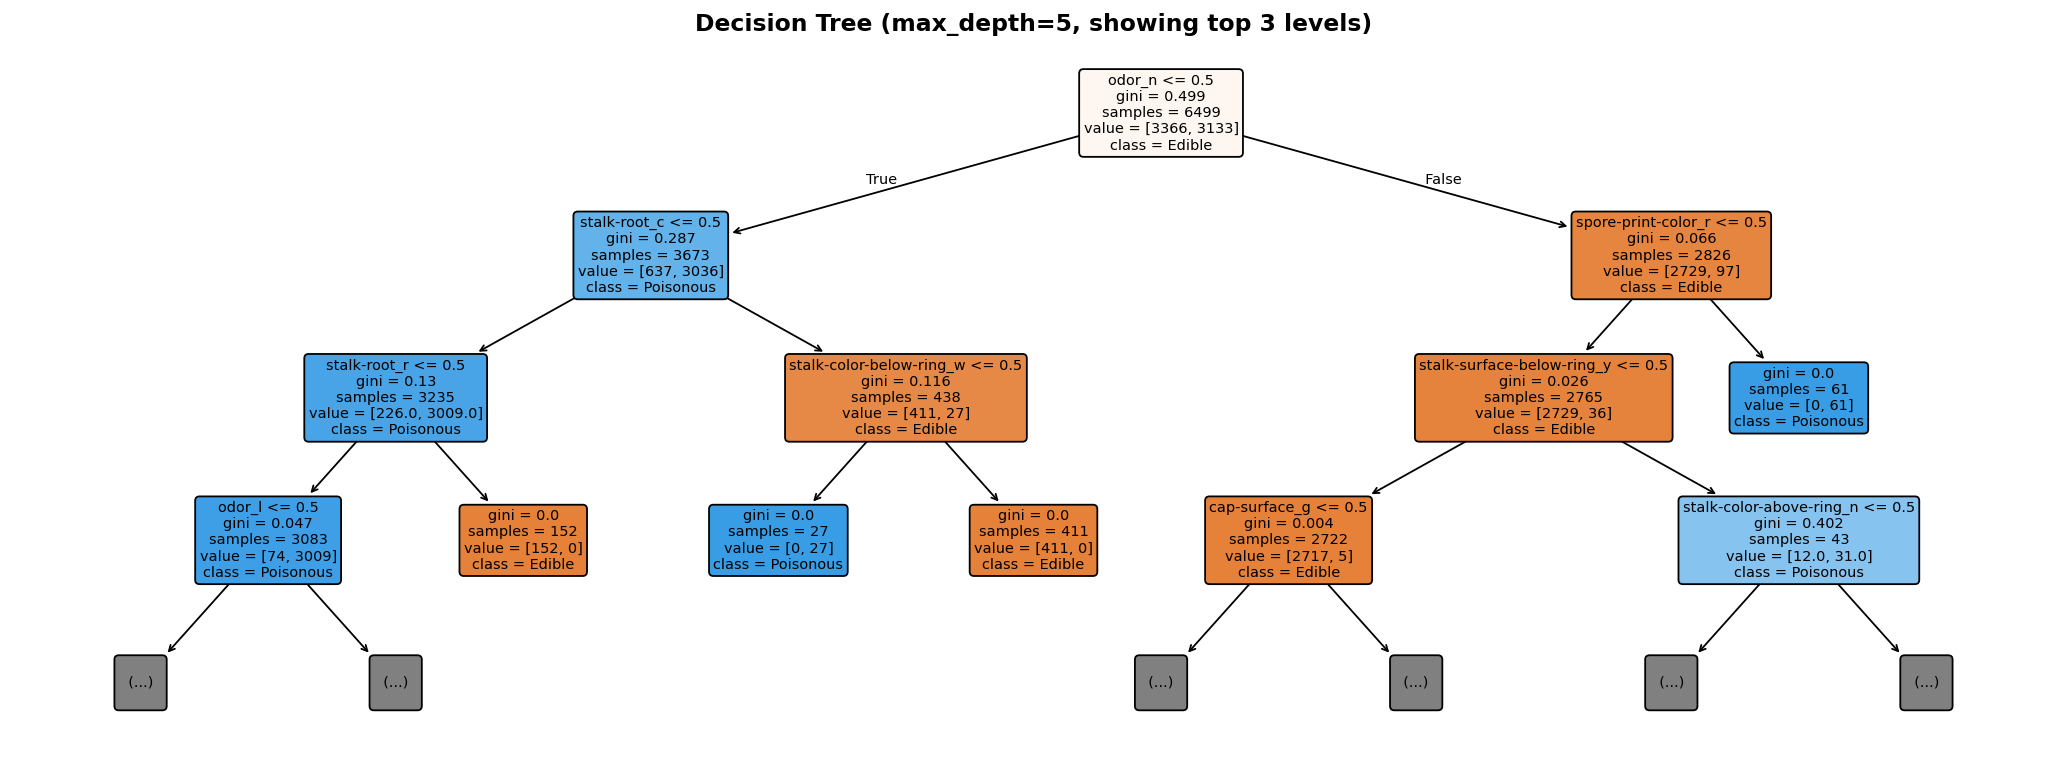

Figure saved: fig_decision_tree.png


In [35]:
# Plot decision tree (top levels only for readability)
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    dt, max_depth=3,
    feature_names=X_mush.columns.tolist(),
    class_names=['Edible', 'Poisonous'],
    filled=True, rounded=True, fontsize=8, ax=ax
)
ax.set_title(f'Decision Tree (max_depth={best_depth}, showing top 3 levels)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_decision_tree.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_decision_tree.png")

In [36]:
# ── Model 3: Random Forest Classifier ────────────────────────
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_m, y_train_m)
y_pred_rf_clf = rf_clf.predict(X_test_m)
y_prob_rf_clf = rf_clf.predict_proba(X_test_m)[:, 1]

print("Random Forest — Classification Report:")
print(classification_report(y_test_m, y_pred_rf_clf,
                             target_names=['Edible', 'Poisonous']))

Random Forest — Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



### 4.4 Results & Evaluation

In [37]:
# ── Metrics comparison table ──────────────────────────────────
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':          accuracy_score(y_true, y_pred),
        'Precision (P)':     precision_score(y_true, y_pred),
        'Recall (P)':        recall_score(y_true, y_pred),
        'F1 (P)':            f1_score(y_true, y_pred),
        'AUC-ROC':           roc_auc_score(y_true, y_prob)
    }

results_clf = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test_m, y_pred_log,     y_prob_log),
    'Decision Tree':       get_metrics(y_test_m, y_pred_dt,      y_prob_dt),
    'Random Forest':       get_metrics(y_test_m, y_pred_rf_clf,  y_prob_rf_clf)
}).T.round(4)

print("=== Classification Model Performance (Test Set) ===")
display(results_clf)

=== Classification Model Performance (Test Set) ===


,Accuracy,Precision (P),Recall (P),F1 (P),AUC-ROC
Logistic Regression,0.9988,1.0000,0.9974,0.9987,1.0000
Decision Tree,0.9963,0.9949,0.9974,0.9962,0.9967
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000


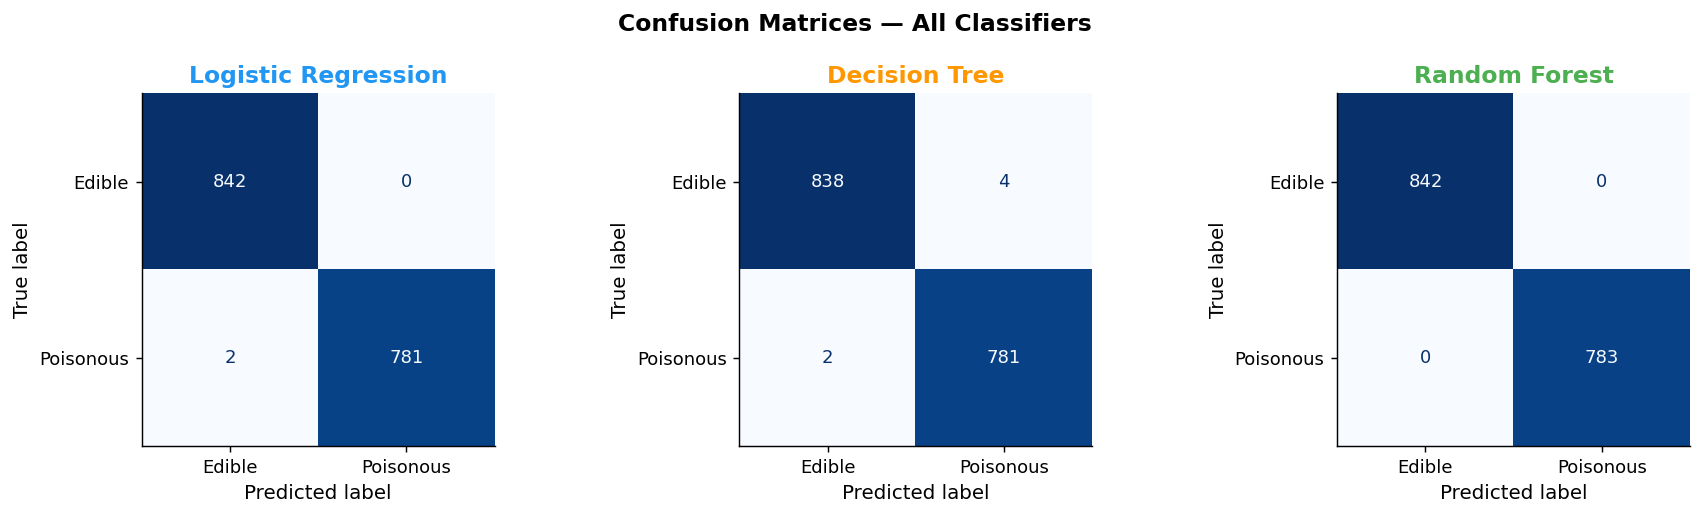

Figure saved: fig_confusion_matrices.png


In [38]:
# ── Confusion matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
clf_info = [
    ('Logistic Regression', y_pred_log,     '#2196F3'),
    ('Decision Tree',       y_pred_dt,      '#FF9800'),
    ('Random Forest',       y_pred_rf_clf,  '#4CAF50')
]

for ax, (name, y_pred, color) in zip(axes, clf_info):
    cm = confusion_matrix(y_test_m, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Edible', 'Poisonous'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')
    ax.title.set_color(color)

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_confusion_matrices.png")

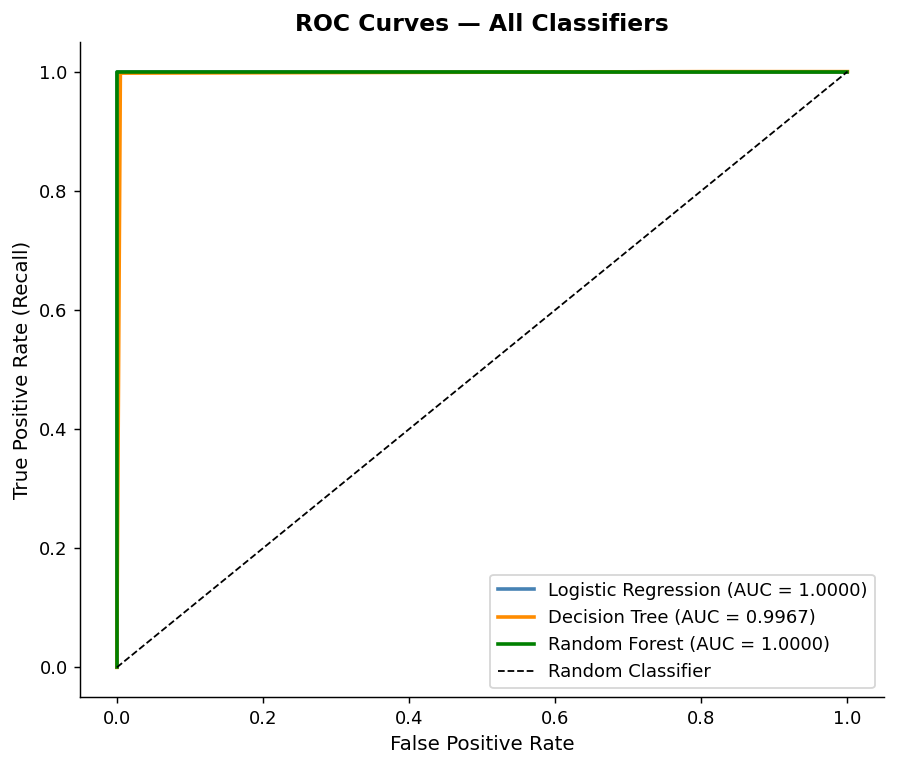

Figure saved: fig_roc_curves.png


In [39]:
# ── ROC Curves ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

roc_models = [
    ('Logistic Regression', y_prob_log,     'steelblue'),
    ('Decision Tree',       y_prob_dt,      'darkorange'),
    ('Random Forest',       y_prob_rf_clf,  'green')
]

for name, y_prob, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test_m, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves — All Classifiers', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_roc_curves.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_roc_curves.png")

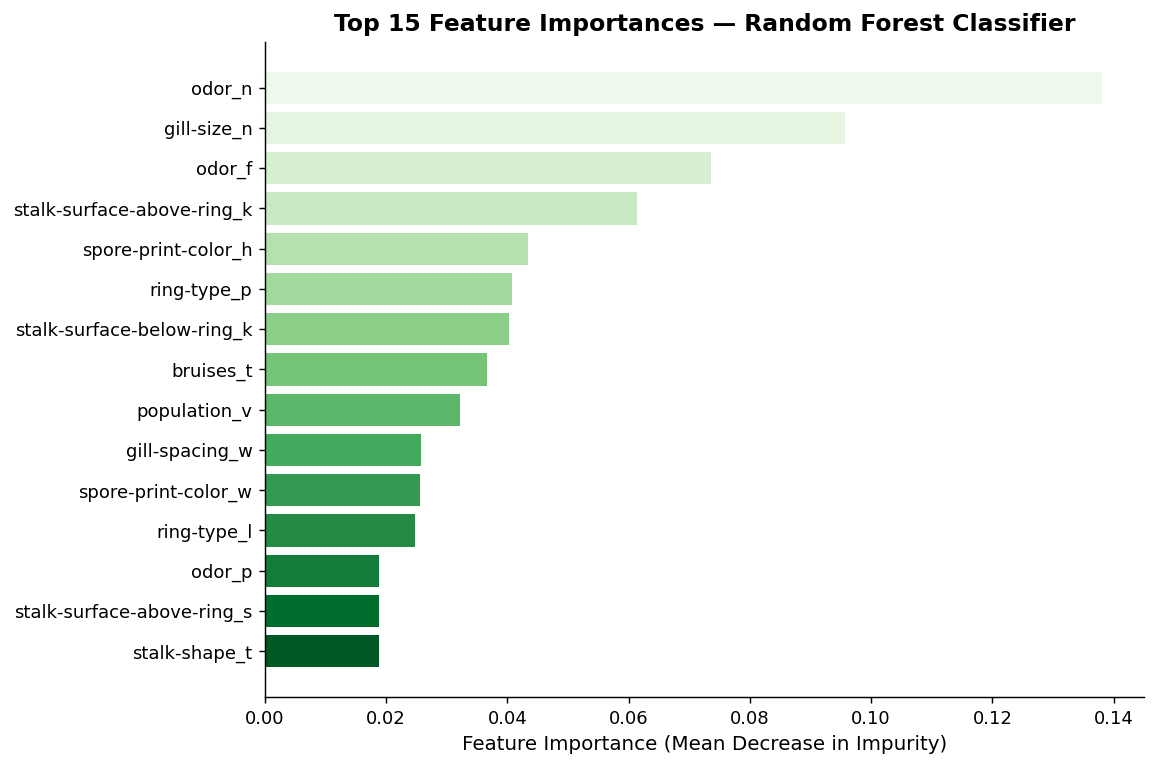

Figure saved: fig_feature_importance_clf.png


In [40]:
# ── Feature importance — Random Forest ───────────────────────
feat_imp_clf = pd.Series(
    rf_clf.feature_importances_, index=X_mush.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_imp_clf.index, feat_imp_clf.values,
        color=sns.color_palette("Greens_r", len(feat_imp_clf)))
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Top 15 Feature Importances — Random Forest Classifier',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance_clf.png', bbox_inches='tight')
plt.show()
print("Figure saved: fig_feature_importance_clf.png")

In [41]:
# ── Summary: most discriminative single features ──────────────
print("=== Top discriminative features (individual accuracy) ===")
top_feats = feat_imp_clf.sort_values(ascending=False).head(5).index.tolist()
for feat in top_feats:
    single_clf = RandomForestClassifier(n_estimators=50, random_state=42)
    score = cross_val_score(single_clf, X_mush[[feat]], y_mush, cv=3,
                            scoring='accuracy').mean()
    print(f"  {feat:45s}: {score*100:.1f}% CV accuracy")

=== Top discriminative features (individual accuracy) ===


  odor_n                                       : 88.7% CV accuracy


  gill-size_n                                  : 75.6% CV accuracy


  odor_f                                       : 78.4% CV accuracy


  stalk-surface-above-ring_k                   : 77.4% CV accuracy


  spore-print-color_h                          : 70.7% CV accuracy


---
## Summary

| Section | Dataset | Task | Models Used |
|---------|---------|------|-------------|
| Unsupervised | FIFA Players | Player archetype discovery | K-Means, Hierarchical (Ward's) |
| Regression | FIFA Players | Market value prediction | Linear Regression, Random Forest, XGBoost |
| Classification | Mushrooms | Edibility prediction | Logistic Regression, Decision Tree, Random Forest |

**All figures are saved as PNG files** in the working directory for inclusion in your Word report.

> **Remember to:** replace `[YOUR CANDIDATE NUMBER]` on the title page, and update `k_optimal` in Section 2.4 based on your elbow/silhouette results.
